In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, itertools, subprocess, sys, shutil,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings, pickle
warnings.filterwarnings("ignore")
from matplotlib.ticker import MaxNLocator

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from inSilicoMut_utils import *

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants[['gene', 'variant']] = who_variants['mutation'].str.split('_', n=1, expand=True)

# use newest V2 results
genomic_coordinates = pd.read_csv("/home/sak0914/who-analysis/results/genomic_coordinates.csv")
genomic_coordinates['REF_len'] = [len(val) for val in genomic_coordinates['reference_nucleotide'].values]
genomic_coordinates['ALT_len'] = [len(val) for val in genomic_coordinates['alternative_nucleotide'].values]
who_variants_V2 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean_V2.csv")#.rename(columns={'POS': 'OLD_POS'})

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
solo_results = pd.read_csv("/home/sak0914/who-analysis/results/SOLO_Final_Aug2023.csv", header=[1])
regression_results =  pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_Nov2023_Tier1.csv")

h37Rv_seq = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

4411532


In [2]:
train_mean, train_sd = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/ridge/train_mean_sd.npy")

In [5]:
train_sd

0.17916273731095195

# 1. Introduce Compatible Mutations from the WHO V2 Catalog into H37Rv

# rpoB and rpoC, Rifampicin

In [2]:
who_variants.query("drug=='RIF' & confidence=='1) Assoc w R'").gene.unique()

array(['rpoB'], dtype=object)

In [5]:
out_dir = f"{data_dir}/RIF/inSilico_analysis"
vcf_dir = f"{out_dir}/synthetic_VCF"
prefix = "rpoBC"
    
# takes a few minutes to run
rpoBC_ALL = get_VCF_file_information("RIF", 
                                     "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC/seqDict.pkl",
                                     prefix,
                                     ["rpoB", "rpoC"], 
                                     "+", 
                                     759309,
                                     767683
                                    )

print(rpoBC_ALL.mutation.nunique(), len(who_variants.query("gene in ['rpoB', 'rpoC'] & ~mutation.str.endswith('?') & ~mutation.str.endswith('fs') & ~mutation.str.endswith('=')")))
rpoBC_ALL.to_csv(f"{out_dir}/{prefix}_WHO_nucleotide_variants.csv", index=False)

# rpoBC_WHO = pd.read_csv(f"{data_dir}/RIF/inSilico_analysis/rpoBC_WHO_nucleotide_variants.csv")
# print(rpoBC_WHO.mutation.nunique(), len(who_variants.query("gene in ['rpoB', 'rpoC']")))

# then write them to new VCF files
# this also creates a file of the mutation names
create_synthetic_VCF_files(rpoBC_ALL, 
                           os.path.join(out_dir, f"{prefix}_WHO_mutations.txt"),
                           vcf_dir
                          )

# then run this for annotation
print(f"\nPlease run\n\nsnpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream {os.path.join(out_dir, f'{prefix}_WHO_mutations.txt')}")

1058 1058
Creating synthetic VCF files for 1058 mutations

Please run

snpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC_WHO_mutations.txt


In [6]:
annotated_VCFs = glob.glob(f"{vcf_dir}/*.eff.vcf")
nonannotated_VCFs = glob.glob(f"{vcf_dir}/*.vcf")
delete_VCFs = list(set(nonannotated_VCFs)-set(annotated_VCFs))

if len(annotated_VCFs) * 2 != len(nonannotated_VCFs) or len(annotated_VCFs) == 0:
    raise ValueError("Please run snpEff annotations first!")

for fName in delete_VCFs:
    os.remove(fName)

pd.Series(annotated_VCFs).to_csv(os.path.join(out_dir, f'{prefix}_WHO_mutations.txt'), index=False, header=None)
print(len(annotated_VCFs))

1058


In [7]:
for fName in glob.glob(f"{vcf_dir}/*.eff.vcf"):

    results = check_annotation_matches_fName(fName)
    found = False
    
    if '_p_' in fName:
        for possibility in results:
            if '_'.join(os.path.basename(fName).split(".")[0].split('_')[1:]) == possibility.replace('.', '_'):
                found = True

        if not found:
            print(fName)

/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF/rpoB_p_Pro15_Ser16insSerPro.eff.vcf


In [5]:
for fName in glob.glob(f"{vcf_dir}/*.eff.vcf"):

    results = check_annotation_matches_fName(fName)
    found = False
    
    if '_p_' in fName:
        for possibility in results:
            if '_'.join(os.path.basename(fName).split(".")[0].split('_')[1:]) == possibility.replace('.', '_'):
                found = True

        if not found:
            print(fName)

/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF/rpoB_p_Pro15_Ser16insSerPro.eff.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF/rpoC_p_Ala1300_Ala1303del.eff.vcf


In [8]:
# should be POS = 763969. This variant is 597C>T
rpoBC_ALL.query("mutation=='rpoB_p.Pro15_Ser16insSerPro'")

,genome_index,confidence,mutation,gene,variant,POS,REF,ALT
270,759827,3) Uncertain significance,rpoB_p.Pro15_Ser16insSerPro,rpoB,p.Pro15_Ser16insSerPro,759851,G,GTCTCCC


In [2]:
Seq.Seq("TCTCCC").translate()

Seq('SP')

In [7]:
fName = '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF/rpoB_p_Pro15_Ser16insSerPro.eff.vcf'
check_annotation_matches_fName(fName)

['c.45_46insTCGCCC', 'p.Ser16_Arg17insProSer']

In [10]:
rpoBC_ALL.query("mutation=='rpoC_p.Ala1300_Ala1303del'")

,gene,variant,mutation,effect,confidence,POS,REF,ALT
2151,rpoC,p.Ala1300_Ala1303del,rpoC_p.Ala1300_Ala1303del,inframe_deletion,3) Uncertain significance,767266,GGCCACCGGTGCT,G


In [11]:
fName = '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF/rpoC_p_Ala1300_Ala1303del.eff.vcf'
check_annotation_matches_fName(fName)

['c.3901_3912delACCGGTGCTGCC', 'p.Thr1301_Ala1304del']

# gyrA and gyrB, Moxifloxacin

In [9]:
who_variants.query("drug=='MXF' & confidence=='1) Assoc w R'").gene.unique()

array(['gyrA', 'gyrB'], dtype=object)

In [11]:
out_dir = f"{data_dir}/MXF/inSilico_analysis"
vcf_dir = f"{out_dir}/synthetic_VCF"
prefix = "gyrBA"

gyrBA_ALL = get_VCF_file_information("MXF", 
                                     "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA/seqDict.pkl",
                                     prefix,
                                     ["gyrA", "gyrB"], 
                                     "+", 
                                     4997, 
                                     9913
                                    )

print(gyrBA_ALL.mutation.nunique(), len(who_variants.query("drug == 'MXF' & gene in ['gyrA', 'gyrB'] & ~mutation.str.endswith('?') & ~mutation.str.endswith('fs') & ~mutation.str.endswith('=')")))
gyrBA_ALL.to_csv(f"{out_dir}/{prefix}_WHO_nucleotide_variants.csv", index=False)

# gyrBA_WHO = pd.read_csv(f"{data_dir}/MXF/inSilico_analysis/gyrBA_WHO_nucleotide_variants.csv")
# print(gyrBA_WHO.mutation.nunique(), len(who_variants.query("drug == 'Moxifloxacin' & gene in ['gyrA', 'gyrB'] & effect not in ['frameshift', 'start_lost', 'stop_lost']")))

# then write them to new VCF files
# this also creates a file of the mutation names
create_synthetic_VCF_files(gyrBA_ALL, 
                           os.path.join(out_dir, f"{prefix}_WHO_mutations.txt"),
                           vcf_dir
                          )

# then run this for annotation
print(f"\nPlease run\n\nsnpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream {os.path.join(out_dir, f'{prefix}_WHO_mutations.txt')}")

543 543
Creating synthetic VCF files for 543 mutations

Please run

snpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt


In [12]:
annotated_VCFs = glob.glob(f"{vcf_dir}/*.eff.vcf")
nonannotated_VCFs = glob.glob(f"{vcf_dir}/*.vcf")
delete_VCFs = list(set(nonannotated_VCFs)-set(annotated_VCFs))

if len(annotated_VCFs) * 2 != len(nonannotated_VCFs) or len(annotated_VCFs) == 0:
    raise ValueError("Please run snpEff annotations first!")

for fName in delete_VCFs:
    os.remove(fName)

pd.Series(annotated_VCFs).to_csv(os.path.join(out_dir, f'{prefix}_WHO_mutations.txt'), index=False, header=None)
print(len(annotated_VCFs))

543


In [13]:
for fName in glob.glob(f"{vcf_dir}/*.eff.vcf"):

    results = check_annotation_matches_fName(fName)
    found = False
    
    if '_p_' in fName:
        for possibility in results:
            if '_'.join(os.path.basename(fName).split(".")[0].split('_')[1:]) == possibility.replace('.', '_'):
                found = True

        if not found:
            print(fName)

In [17]:
fName = '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/synthetic_VCF/gyrA_p_Glu820_Ter839del.eff.vcf'
check_annotation_matches_fName(fName)

['c.2277_2336delGAAGAAAGTGGCGACGATAATGCCGTGGACGCCAACGGCGCAGACCAGACGGGCAATTAA',
 'p.Gly760_Ser779del']

In [18]:
gyrBA_ALL.query("mutation=='gyrA_p.Glu820_Ter839del'")

,gene,variant,mutation,effect,confidence,POS,REF,ALT
552,gyrA,p.Glu820_Ter839del,gyrA_p.Glu820_Ter839del,inframe_deletion,3) Uncertain significance,9758,CGAAGAAAGTGGCGACGATAATGCCGTGGACGCCAACGGCGCAGAC...,C


In [25]:
test_seq = gyrBA_ALL.query("mutation=='gyrA_p.Glu820_Ter839del'").REF.values[0][1:]
Seq.Seq(test_seq), Seq.Seq(test_seq).translate()

(Seq('GAAGAAAGTGGCGACGATAATGCCGTGGACGCCAACGGCGCAGACCAGACGGGCAATTAA'),
 Seq('EESGDDNAVDANGADQTGN*'))

# pncA, Pyrazinamide

In [2]:
who_variants.query("drug=='PZA' & confidence=='1) Assoc w R'").gene.unique()

array(['pncA'], dtype=object)

In [2]:
out_dir = f"{data_dir}/PZA/inSilico_analysis"
vcf_dir = f"{out_dir}/synthetic_VCF"
prefix = "pncA"

pncA_ALL = get_VCF_file_information("PZA", 
                                     "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/seqDict.pkl",
                                     prefix,
                                     ["pncA"], 
                                     "-", 
                                     2286526, 
                                     2291268
                                    )

print(pncA_ALL.mutation.nunique(), len(who_variants.query("gene in ['pncA'] & ~mutation.str.endswith('?') & ~mutation.str.endswith('fs') & ~mutation.str.endswith('=')")))
pncA_ALL.to_csv(f"{out_dir}/{prefix}_WHO_nucleotide_variants.csv", index=False)

# pncA_WHO = pd.read_csv(f"{out_dir}/{prefix}_WHO_nucleotide_variants.csv")
# print(pncA_WHO.mutation.nunique(), len(who_variants.query("gene in ['pncA'] & effect not in ['frameshift', 'start_lost', 'stop_lost']")))

# then write them to new VCF files
# this also creates a file of the mutation names
create_synthetic_VCF_files(pncA_ALL, 
                           os.path.join(out_dir, f"{prefix}_WHO_mutations.txt"),
                           vcf_dir
                          )

# then run this for annotation
print(f"\nPlease run\n\nsnpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream {os.path.join(out_dir, f'{prefix}_WHO_mutations.txt')}")

362 362
Creating synthetic VCF files for 362 mutations

Please run

snpEff eff Mycobacterium_tuberculosis_gca_000195955 -noStats -fileList -no-downstream -no-upstream /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/pncA_WHO_mutations.txt


In [5]:
annotated_VCFs = glob.glob(f"{vcf_dir}/*.eff.vcf")
nonannotated_VCFs = glob.glob(f"{vcf_dir}/*.vcf")
delete_VCFs = list(set(nonannotated_VCFs)-set(annotated_VCFs))

if len(annotated_VCFs) * 2 != len(nonannotated_VCFs) or len(annotated_VCFs) == 0:
    raise ValueError("Please run snpEff annotations first!")

for fName in delete_VCFs:
    os.remove(fName)

pd.Series(annotated_VCFs).to_csv(os.path.join(out_dir, f'{prefix}_WHO_mutations.txt'), index=False, header=None)
print(len(annotated_VCFs))

362


In [6]:
for fName in glob.glob(f"{vcf_dir}/*.eff.vcf"):

    results = check_annotation_matches_fName(fName)
    found = False
    
    if '_p_' in fName:
        for possibility in results:
            if '_'.join(os.path.basename(fName).split(".")[0].split('_')[1:]) == possibility.replace('.', '_').replace('*', '+'):
                found = True

        if not found:
            print(fName)

/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/synthetic_VCF/pncA_p_Ala89_Ala92dup.eff.vcf


In [7]:
pncA_ALL.query("mutation=='pncA_p.Ala89_Ala92dup'")

,confidence,mutation,gene,variant,POS,REF,ALT
134,2) Assoc w R - Interim,pncA_p.Ala89_Ala92dup,pncA,p.Ala89_Ala92dup,2288965,C,CCGCCTCGATTGC


In [ ]:
p.Ala92_Val93insAlaIleGluAla

In [8]:
Seq.Seq("CGCCTCGATTGC").reverse_complement().translate()

Seq('AIEA')

# Remove mutations that increase the alignment lengths so that the matrix can be passed into pre-trained models

In [2]:
def remove_mutations_to_preserve_aln(model_aln_df, full_aln_df, START, vcf_df):
    
    print(f"Original aln insertions: {model_aln_df['len_insertion'].sum()}")
    print(f"In silico aln insertions: {full_aln_df['len_insertion'].sum()}")
    
    model_aln_df["name"] = "old"
    full_aln_df["name"] = "new"

    insertions_combined = model_aln_df.merge(full_aln_df, on="aln_idx", how="outer")

    # idx + START + 1 = record.POS. Add 1 to START because it is 0-indexed
    insertions_combined["POS"] = insertions_combined["aln_idx"] + START + 1
    
    # x = old, y = new
    search_df = insertions_combined.loc[insertions_combined['len_insertion_x'] != insertions_combined['len_insertion_y']]#insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]

    vcf_df["REF_len"] = [len(val) for val in vcf_df["REF"]]
    vcf_df["ALT_len"] = [len(val) for val in vcf_df["ALT"]]

    drop_mutations = vcf_df.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values
    print(drop_mutations)
    print(f"Dropped {len(drop_mutations)} mutations to preserve the alignment")

    vcf_df_cleaned = vcf_df.query("mutation not in @drop_mutations")
    print(len(vcf_df.mutation.unique()), len(vcf_df_cleaned.mutation.unique()))
    
    return vcf_df_cleaned
    
    
    
def remove_mutations_to_preserve_aln_create_new_files(drug, locus, START):

    # original dataframe of insertions when the original data were aligned
    model_aln_df = pd.read_csv(os.path.join(data_dir, drug, "fastas", f"{locus}_insertion_sites.csv"))

    # isolates above + WHO mutations for insilico validation
    insilico_aln_df = pd.read_csv(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_insertion_sites.csv"))

    # change the name of the insertion sites file so that the new one will appear when make_MSA.py is rerun
    os.rename(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_insertion_sites.csv"), os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_insertion_sites_original.csv"))

    vcf_df = pd.read_csv(f"{data_dir}/{drug}/inSilico_analysis/{locus}_WHO_nucleotide_variants.csv")

    # change the file name to keep the original
    os.rename(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_nucleotide_variants.csv"), os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_nucleotide_variants_original.csv"))

    # remove mutations, then save to the original file name
    vcf_df_cleaned = remove_mutations_to_preserve_aln(model_aln_df, insilico_aln_df, START, vcf_df)
    vcf_df_cleaned.to_csv(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_nucleotide_variants.csv"), index=False)

    fNames_lst = pd.read_csv(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_mutations.txt"), sep="\t", header=None).rename(columns={0: 'fName'})

    # change the file name to keep the original
    os.rename(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_mutations.txt"), os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_mutations_original.txt"))

    # revert the names to the original form. The file names have been altered to remove some special characters. ">" is a special character and has been left in, however. The biggest issue was the "*" character in stop codons
    fNames_lst["mutation"] = [os.path.basename(val).split(".")[0].replace("+", "*").replace("p_", "p.").replace("c_", "c.").replace("n_", "n.") for val in fNames_lst['fName'].values]

    # keep only those in the WHO nucleotide variants dataframe
    print(f"Kept {len(fNames_lst.loc[fNames_lst['mutation'].isin(vcf_df_cleaned['mutation'].values)])} mutations for {drug}")
    
    fNames_lst.loc[fNames_lst["mutation"].isin(vcf_df_cleaned["mutation"].values)]['fName'].to_csv(os.path.join(data_dir, drug, "inSilico_analysis", f"{locus}_WHO_mutations.txt"), index=False, header=None, sep="\t")

In [3]:
remove_mutations_to_preserve_aln_create_new_files("RIF", "rpoBC", 759309)

Original aln insertions: 156
In silico aln insertions: 244
['rpoB_p.Thr444dup' 'rpoB_c.-121_-120insT' 'rpoB_c.-151_-150insGT'
 'rpoB_c.-159_-158insT' 'rpoB_c.-165_-164insG'
 'rpoB_c.-180_-179insCTTGACACCGTGGTCTTAGTC' 'rpoB_p.Pro15_Ser16insSerPro'
 'rpoB_c.-264_-263insTT' 'rpoB_c.-42_-41insT' 'rpoB_c.-59_-58insT'
 'rpoC_p.Gln1084_Arg1085dup' 'rpoB_p.Arg499_Asn501dup'
 'rpoB_p.Phe503_Thr508dup' 'rpoB_p.Met97_Ser98dup' 'rpoB_c.-80_-79insTT'
 'rpoB_c.-169_-168insA' 'rpoC_c.-42_-41insT' 'rpoB_p.Asp853_Glu854dup']
Dropped 18 mutations to preserve the alignment
1058 1040
Kept 1040 mutations for RIF


In [4]:
remove_mutations_to_preserve_aln_create_new_files("MXF", "gyrBA", 4997)

Original aln insertions: 12
In silico aln insertions: 14
['gyrB_c.-60_-59insG' 'gyrB_c.-60_-59insGC']
Dropped 2 mutations to preserve the alignment
543 541
Kept 541 mutations for MXF


In [5]:
remove_mutations_to_preserve_aln_create_new_files("PZA", "pncA", 2286526)

Original aln insertions: 70
In silico aln insertions: 155
['pncA_p.Val155dup' 'pncA_p.Asp12_Phe13insAlaSerGluProProSerGlnLysSer'
 'pncA_p.Ser65_Ser66insAspTyrSer' 'pncA_p.Ala89_Ala92dup'
 'pncA_p.Lys96delinsAsnLeuAlaIleSerAsnValIleValAspGlyVal'
 'pncA_c.-30_-29insC' 'pncA_c.-33_-32insG' 'pncA_c.-3_-2insC']
Dropped 8 mutations to preserve the alignment
362 354
Kept 354 mutations for PZA


# Create file for other loci in the models without in silico mutations

Copy the H37Rv sequence for all in silico mutations in other loci

In [2]:
def write_ref_seqs_for_constant_loci(drug, variable_locus, variable_genes_lst, constant_locus_lst):

    seq_with_variants = [seq.id for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/{variable_locus}.fasta", "fasta")]

    for constant_locus in constant_locus_lst:
    
        # get the reference sequence for the locus
        locus_seq = [(seq.id, seq.seq) for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/fastas/{constant_locus}.fasta", "fasta")]
        ref_seq = str(locus_seq[-1][1])
        print(constant_locus, len(ref_seq))
        
        with open(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/{constant_locus}.fasta", "w+") as file:
            for seq in seq_with_variants:
                for variable_gene in variable_genes_lst:
                    if variable_gene in seq:
                        file.write(">" + seq + "\n")
                        file.write(ref_seq + "\n")
                        break

In [7]:
write_ref_seqs_for_constant_loci('PZA', 'pncA', ['pncA'], ['clpC1', 'rpsA', 'panD'])

clpC1 2930
rpsA 3008
panD 3362


In [3]:
write_ref_seqs_for_constant_loci('RIF', 'rpoBC', ['rpoB', 'rpoC'], ['rpoA'])

rpoA 1075


# 2. Analysis of in silico mutagenesis

# 2.1: Compare in silico WHO catalog predictions between the -Peptide and +Peptide Models

In [3]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_dir, "PZA", "isolate_variants.csv.gz"), compression='gzip')

PZA_isolate_variants["REF_len"] = [len(val) for val in PZA_isolate_variants.REF.values]
PZA_isolate_variants["ALT_len"] = [len(val) for val in PZA_isolate_variants.ALT.values]

In [4]:
PZA_peptide_insilico_pred = pd.read_csv("PZA/insilico_mutagenesis/pncA_WHO_predictions_lineage_peptide.csv")
PZA_peptide_insilico_pred["CNN_MIC"] = np.exp2(PZA_peptide_insilico_pred['CNN_log_MIC'])

PZA_insilico_pred = pd.read_csv("PZA/insilico_mutagenesis/pncA_WHO_predictions_lineage.csv")
PZA_insilico_pred["CNN_MIC"] = np.exp2(PZA_insilico_pred['CNN_log_MIC'])

for i, row in PZA_peptide_insilico_pred.iterrows():

    if "_p_" in row["mutation"]:

        num = []
        for char in row["mutation"].split("_")[-1]:
            if char.isnumeric():
                num.append(char)
        PZA_peptide_insilico_pred.loc[i, "codon_num"] = int("".join(num))
    else:
        PZA_peptide_insilico_pred.loc[i, "codon_num"] = 0

combined_insilico_df = PZA_peptide_insilico_pred.rename(columns={'CNN_MIC': 'PZA_peptide_pred_MIC', 'CNN_log_MIC': 'PZA_peptide_pred_log_MIC'}).merge(PZA_insilico_pred[['mutation', 'CNN_MIC', 'CNN_log_MIC']].rename(columns={'CNN_MIC': 'PZA_pred_MIC', 'CNN_log_MIC': 'PZA_pred_log_MIC'}), on='mutation')

# 2.2 Compare test set predictions between the -Peptide and +Peptide Models

In [5]:
df_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))
locus_peptide_lengths = pd.read_csv(os.path.join(results_dir, "PZA_4Loci", "gene_peptide_lengths.csv"), index_col=[0])

PZA_pred = pd.read_csv(os.path.join(results_dir, "PZA_4Loci_lineage", "test_predictions.csv"))
PZA_peptide_pred = pd.read_csv(os.path.join(results_dir, "PZA_4Loci_peptide_lineage", "test_predictions.csv"))

combined_pred_df = PZA_pred[['Isolate', 'y_pred', 'y_test', 'lower', 'upper']].merge(PZA_peptide_pred[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_peptide_pred'}), on='Isolate')
combined_pred_df['y_pred_MIC'] = np.exp2(combined_pred_df['y_pred'])
combined_pred_df['y_peptide_pred_MIC'] = np.exp2(combined_pred_df['y_peptide_pred'])

lower_bounds = combined_pred_df['lower'].values
upper_bounds = combined_pred_df['upper'].values

# add a tiny amount so they can be log-transformed, then log-transform
lower_bounds[lower_bounds==0] += 1e-6
lower_bounds = np.log2(lower_bounds)
upper_bounds = np.log2(upper_bounds)

# determine whether to compute error from the bounds or if the error is 0. 
bound_to_compute_error = np.clip(combined_pred_df['y_pred'].values, lower_bounds, upper_bounds)
errors = np.abs(bound_to_compute_error - combined_pred_df['y_pred'].values)

# use less than or equal to because the true MIC is in the range (lower, upper], so it is not equal to lower.
outside_bounds_mask = (np.less_equal(combined_pred_df['y_pred'].values, lower_bounds) | np.greater(combined_pred_df['y_pred'].values, upper_bounds)).astype(int)

# multiply so that the points predicted in their bin are multiplied by 0 so they have 0 error
combined_pred_df["error"] = outside_bounds_mask * errors

# determine whether to compute error from the bounds or if the error is 0. 
bound_to_compute_error = np.clip(combined_pred_df['y_peptide_pred'].values, lower_bounds, upper_bounds)
errors = np.abs(bound_to_compute_error - combined_pred_df['y_peptide_pred'].values)

# use less than or equal to because the true MIC is in the range (lower, upper], so it is not equal to lower.
outside_bounds_mask = (np.less_equal(combined_pred_df['y_peptide_pred'].values, lower_bounds) | np.greater(combined_pred_df['y_peptide_pred'].values, upper_bounds)).astype(int)

# multiply so that the points predicted in their bin are multiplied by 0 so they have 0 error
combined_pred_df["error_peptide"] = outside_bounds_mask * errors

catalog_pred = pd.read_csv(os.path.join(results_dir, "PZA_4Loci", "catalog_test_predictions.csv"))
combined_pred_df = combined_pred_df.merge(catalog_pred[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_pred_catalog'}), on='Isolate')

# samples in the test set with early stop codons (including ambiguous ones that aren't reflected in the lengths because translation of a codon containing N will not be the stop codon)
isolates_with_pncA_disruption = PZA_isolate_variants.query("POS > 2286526 & POS <= 2291268 & GENE.str.contains('pncA') & EFFECT.str.contains('|'.join(['stop_gained', 'ablation', 'gene_fusion']))").Isolate.values
print(f"{len(isolates_with_pncA_disruption)} total isolates with pncA disruptions")

# pncA_disrupted_test_data = combined_pred_df.query("Isolate in @isolates_with_pncA_disruption").melt(id_vars='Isolate', value_vars=['y_peptide_pred', 'y_pred']).rename(columns={'Isolate': 'mutation'})
print(f"{combined_pred_df.query('Isolate in @isolates_with_pncA_disruption').Isolate.nunique()} test isolates with pncA disruptions")

# pncA_disrupted_test_data['variable'] = pncA_disrupted_test_data['variable'].replace('y_pred', '- Peptide Lengths').replace('y_peptide_pred', '+ Peptide Lengths')
# pncA_disrupted_test_data['value'] = np.exp2(pncA_disrupted_test_data['value']) # these are currently log2-transformed
# pncA_disrupted_test_data['mutation'] = [val + ' (>500)' for val in pncA_disrupted_test_data['mutation'].values]

# combine them to plot on the same graph. Exclude stop lost variants because it's not clear how much longer the pncA protein goes on
insilico_disrupted_df_plot = combined_insilico_df.query("mutation.str.contains('\\+')").melt(id_vars=['mutation', 'codon_num'], value_vars=['PZA_peptide_pred_MIC', 'PZA_pred_MIC']).sort_values('codon_num', ascending=True).reset_index(drop=True)

insilico_disrupted_df_plot['variable'] = insilico_disrupted_df_plot['variable'].replace('PZA_pred_MIC', '- Peptide').replace('PZA_peptide_pred_MIC', '+ Peptide')

# insilico_disrupted_df_plot = pd.concat([insilico_disrupted_df_plot, pncA_disrupted_test_data])

32 total isolates with pncA disruptions
4 test isolates with pncA disruptions


In [74]:
# on average, peptide model reduces MIC predictions
np.mean(combined_pred_df['y_peptide_pred'] - combined_pred_df['y_pred']), np.median(combined_pred_df['y_peptide_pred'] - combined_pred_df['y_pred'])

(-0.2264959674876848, -0.009282000000000679)

In [234]:
combined_pred_df.shape, combined_pred_df.query("Isolate not in @isolates_with_pncA_disruption").shape

((203, 11), (199, 11))

In [73]:
np.mean(combined_pred_df.query("Isolate not in @isolates_with_pncA_disruption")['y_peptide_pred'] - combined_pred_df.query("Isolate not in @isolates_with_pncA_disruption")['y_pred']), np.median(combined_pred_df.query("Isolate not in @isolates_with_pncA_disruption")['y_peptide_pred'] - combined_pred_df.query("Isolate not in @isolates_with_pncA_disruption")['y_pred'])

(-0.08101966532663321, -0.009282000000000679)

In [81]:
np.mean(combined_insilico_df.query("mutation != 'MT_H37Rv'")['PZA_peptide_pred_log_MIC'] - combined_insilico_df.query("mutation != 'MT_H37Rv'")['PZA_pred_log_MIC']), np.median(combined_insilico_df.query("mutation != 'MT_H37Rv'")['PZA_peptide_pred_log_MIC'] - combined_insilico_df.query("mutation != 'MT_H37Rv'")['PZA_pred_log_MIC'])

(-0.09469310254237291, -0.1217261999999999)

In [269]:
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,y_pred_MIC,y_peptide_pred_MIC,error,error_peptide
93,Peru4070,54.054092,8.965784,500.0,inf,46.388250,1.870265e+16,9.209895e+13,0.0,0.0
178,Peru5003,60.057438,8.965784,500.0,inf,36.080456,1.199749e+18,7.266069e+10,0.0,0.0
184,Peru5077,9.045805,8.965784,500.0,inf,9.881677,5.285166e+02,9.433681e+02,0.0,0.0
195,Peru5149,9.508786,8.965784,500.0,inf,10.459970,7.285004e+02,1.408526e+03,0.0,0.0


In [275]:
PZA_isolate_variants.query("Isolate=='NLA009701714' & POS >= 2286527 & POS <= 2291268")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,REF_len,ALT_len
225809,2287121,A,G,PASS,1.0,Rv2041c,synonymous_variant,c.726T>C,p.Asp242Asp,NLA009701714,1,1
225810,2288085,G,C,PASS,1.0,Rv2042c,synonymous_variant,c.597C>G,p.Ala199Ala,NLA009701714,1,1
225811,2288728,GCGCGGCGACGGTGGTATCGGCCGACACACCCGCTGT,G,PASS,0.33,pncA,conservative_inframe_deletion,c.478_513delACAGCGGGTGTGTCGGCCGATACCACCGTCGCCGCG,p.Thr160_Ala171del,NLA009701714,37,1


In [6]:
def plot_change_MIC_predictions(df, figsize=(6.4, 5.8), saveName=None):

    fig, ax = plt.subplots(figsize=figsize)

    # back to original naming convention. Also remove the gene prefix because they are all the same gene
    df["mutation"] = [variant.split("_")[-1].replace('+', '*') for variant in df["mutation"].values]
    
    sns.stripplot(data=df,
                  x='value',
                  y='mutation',
                  hue='variable',
                  hue_order=['- Peptide', '+ Peptide'],
                  palette='colorblind',
                  log_scale=10,
                  size=6,
                  edgecolor='black',
                  linewidth=1,
                  jitter=False,
                  ax=ax,
                  zorder=2
                 )
    
    plt.hlines(y=ax.get_yticks(), xmin=df.query("variable=='- Peptide'")['value'].values, 
               xmax=df.query("variable=='+ Peptide'")['value'].values, 
               color='darkgray',
               linewidth=1,
               zorder=1
              )
    
    # plt.axvline(x=100, color='black', linewidth=0.75, linestyle='--', zorder=0, label='CC = 100')
    # plt.axvline(x=500, color='black', linewidth=0.75, linestyle='--', zorder=0, label='MIC = 500')
    
    plt.legend(title='', loc='best', fontsize='9')
    plt.xlabel('Predicted MIC (µg/mL)')
    plt.ylabel("")
    plt.xlim(left=10)
    sns.despine()

    if saveName is not None:
        plt.savefig(saveName, bbox_inches='tight', dpi=300)
    else:
        plt.show()

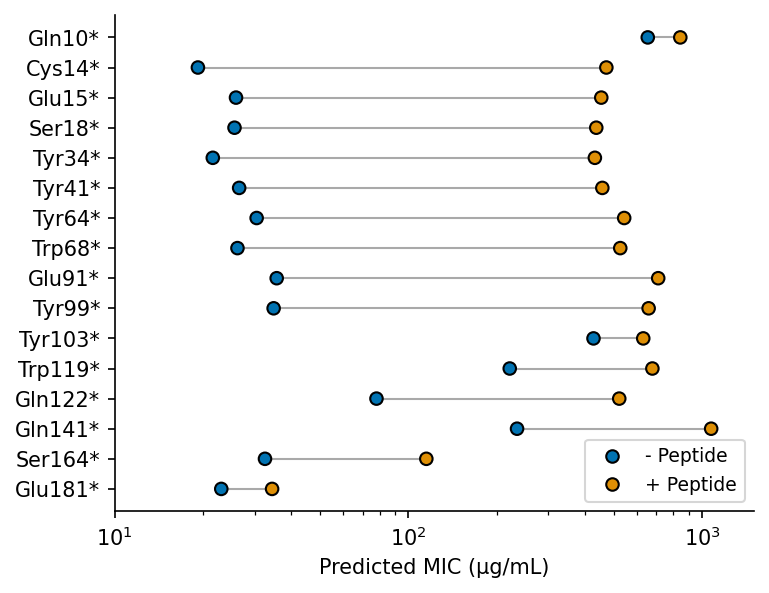

In [27]:
plot_change_MIC_predictions(insilico_disrupted_df_plot, figsize=(5.5, 4.3), saveName="PZA/insilico_mutagenesis/with_without_peptide_lengths.png")

In [28]:
# plot_change_MIC_predictions(insilico_disrupted_df_plot, saveName="PZA/insilico_mutagenesis/with_without_peptide_lengths_V2.png")

In [101]:
insilico_disrupted_df_plot.query("mutation.str.contains('\\+') & variable == '- Peptide' & value > 100")

,mutation,codon_num,variable,value
1,pncA_p_Gln10+,10.0,- Peptide,501.038620
22,pncA_p_Tyr95+,95.0,- Peptide,108.226629
28,pncA_p_Tyr103+,103.0,- Peptide,427.226995
37,pncA_p_Gln122+,122.0,- Peptide,155.556654
39,pncA_p_Gln141+,141.0,- Peptide,234.581430


In [105]:
insilico_disrupted_df_plot.query("mutation.str.contains('\\+') & variable == '+ Peptide' & value > 100").shape, insilico_disrupted_df_plot.mutation.nunique()

((23, 4), 25)

In [103]:
# cases where the peptide model predicted S
insilico_disrupted_df_plot.query("mutation.str.contains('\\+') & variable == '+ Peptide' & value <= 100")

,mutation,codon_num,variable,value
44,pncA_p_Glu173+,173.0,+ Peptide,59.953426
48,pncA_p_Glu181+,181.0,+ Peptide,35.636963


In [106]:
insilico_disrupted_df_plot.query("mutation=='pncA_p_Glu174+'")

,mutation,codon_num,variable,value
46,pncA_p_Glu174+,174.0,- Peptide,48.885181
47,pncA_p_Glu174+,174.0,+ Peptide,169.520660


In [108]:
cc = np.log2(100)
# RESISTANT SAMPLES THAT THE PEPTIDE MODEL MISSED BUT THE ORIGINAL MODEL GOT. All near the border, MIC = 100 - 150, so doesn't exactly mean that the peptide model is bad
# BUT ACTUALLY THE OVERALL ERROR BETTER OF THE PEPTIDE MODEL IS LESS HAHAHAHAH
combined_pred_df.query("y_test >= @cc & y_pred >= @cc & y_peptide_pred <= @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff,error,error_peptide
167,Peru4930,7.174232,6.781360,100.0,120.0,6.575475,-0.598757,-49.059755,0.267341,0.068381
176,Peru4997,9.199295,6.781360,100.0,120.0,6.334726,-2.864569,-507.133385,2.292404,0.309130
198,Peru5415,7.174232,7.076816,120.0,150.0,6.575475,-0.598757,-49.059755,0.000000,0.331416


In [115]:
PZA_isolate_variants.query("Isolate in ['Peru4930', 'Peru4997', 'Peru5415'] & POS >= 2286527 & POS <= 2291268")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,REF_len,ALT_len
1276101,2287121,A,G,PASS,1.0,Rv2041c,synonymous_variant,c.726T>C,p.Asp242Asp,Peru4930,1,1
1276102,2289207,T,G,PASS,1.0,pncA,missense_variant,c.35A>C,p.Asp12Ala,Peru4930,1,1
1362429,2287121,A,G,PASS,1.0,Rv2041c,synonymous_variant,c.726T>C,p.Asp242Asp,Peru4997,1,1
1362430,2288824,G,GC,PASS,1.0,pncA,frameshift_variant,c.417dupG,p.Arg140fs,Peru4997,1,2
1540434,2287121,A,G,PASS,1.0,Rv2041c,synonymous_variant,c.726T>C,p.Asp242Asp,Peru5415,1,1
1540435,2289207,T,G,PASS,1.0,pncA,missense_variant,c.35A>C,p.Asp12Ala,Peru5415,1,1


In [123]:
gene_peptide_lengths = pd.read_csv(os.path.join(results_dir, "PZA_4Loci", "gene_peptide_lengths.csv"), index_col=[0])

In [125]:
gene_peptide_lengths.loc[['Peru4930', 'Peru5415', 'Peru4997']]

,Rv2041c_length,Rv2042c_length,pncA_length,Rv2044c_length,lipT_length,Rv3599c_length,Rv3600c_length,panD_length,panC_length,Rv3603c_length,rpsA_length,coaE_length,clpC1_length
Peru4930,439,265,186,105,511,27,272,139,309,303,481,407,848
Peru5415,439,265,186,105,511,27,272,139,309,303,481,407,848
Peru4997,439,265,187,105,511,27,272,139,309,303,481,407,848


In [118]:
who_variants.query("mutation in ['pncA_p.Asp12Ala', 'pncA_p.Arg140fs']")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35707,Pyrazinamide,pncA,p.Arg140fs,pncA_p.Arg140fs,1,frameshift,1.0,6.0,6.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,no,Interim on WHO,NaN,1,2288818
35735,Pyrazinamide,pncA,p.Asp12Ala,pncA_p.Asp12Ala,1,missense_variant,1.0,25.0,18.0,7.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,2289207


In [107]:
# RESISTANT SAMPLES THAT THE PEPTIDE MODEL GOT BUT THE ORIGINAL MODEL MISSED
combined_pred_df.query("y_test >= @cc & y_pred <= @cc & y_peptide_pred > @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff,error,error_peptide
112,Peru4309,5.415115,8.965784,500.0,inf,8.932659,3.517544,445.981476,3.550669,0.033125
133,Peru4565,3.923385,8.965784,500.0,inf,9.069377,5.145992,522.050423,5.042399,0.000000
150,Peru4679,4.261074,8.965784,500.0,inf,7.861713,3.600640,213.427063,4.704711,1.104071
156,Peru4709,6.148060,8.965784,500.0,inf,9.262963,3.114903,543.452572,2.817724,0.000000
166,Peru4929,6.174985,8.965784,500.0,inf,9.810628,3.635643,825.782094,2.790799,0.000000
183,Peru5071,6.255681,7.965784,200.0,300.0,7.482691,1.227010,102.450953,1.388175,0.161165
185,Peru5083,5.470185,8.965784,500.0,inf,6.958789,1.488604,80.066185,3.495599,2.006995


In [74]:
np.log2(500)

8.965784284662087

In [48]:
# RESISTANT SAMPLES THAT BOTH MODELS MISSED
combined_pred_df.query("y_test >= @cc & y_pred <= @cc & y_peptide_pred <= @cc").shape

(28, 8)

In [49]:
# 0 cases where they are both predicted susceptible -- GOOD
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption & y_pred < @cc & y_peptide_pred < @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff


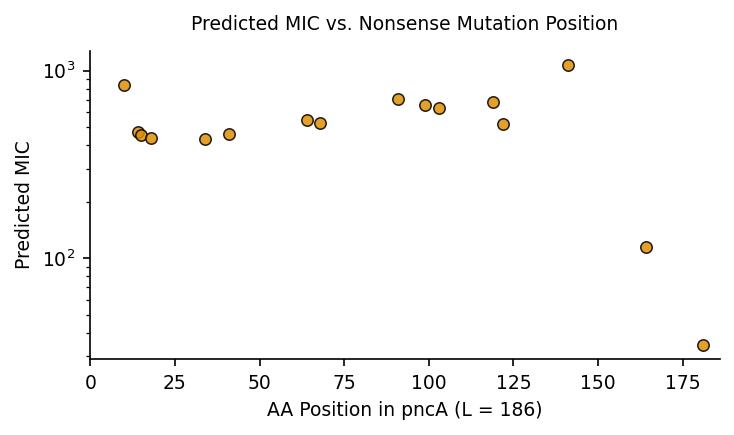

In [29]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=insilico_disrupted_df_plot.query("variable == '+ Peptide'"),
                x="codon_num",
                y="value",
                s=30,
                color=sns.color_palette('colorblind').as_hex()[1],
                edgecolor='black',
                linewidth=0.75,
                alpha=0.85,
                ax=ax
               )

plt.xlabel("AA Position in pncA (L = 186)", fontsize=9)
plt.ylabel("Predicted MIC", fontsize=9)
plt.title("Predicted MIC vs. Nonsense Mutation Position", fontsize=9)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.xlim(left=0, right=186)
plt.yscale('log')
plt.tight_layout()
sns.despine()
plt.savefig("PZA/insilico_mutagenesis/predicted_MICs_by_nonsense_pos.png", dpi=300, bbox_inches="tight")

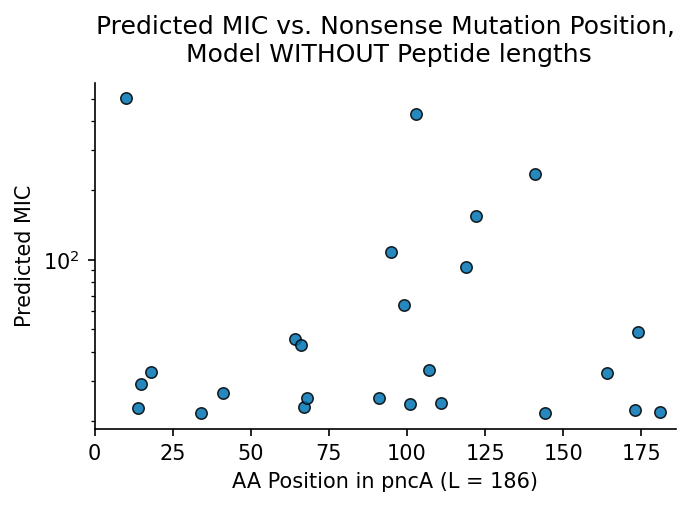

In [51]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=insilico_disrupted_df_plot.query("variable == '- Peptide'"),
                x="codon_num",
                y="value",
                s=30,
                color=sns.color_palette('colorblind').as_hex()[0],
                edgecolor='black',
                linewidth=0.75,
                alpha=0.85,
                ax=ax
               )

plt.xlabel("AA Position in pncA (L = 186)")
plt.ylabel("Predicted MIC")
plt.title("Predicted MIC vs. Nonsense Mutation Position,\n Model WITHOUT Peptide lengths")

plt.xlim(left=0, right=186)
plt.yscale('log')
sns.despine()
plt.show()

# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv), using script

In [7]:
def get_predictions_dataframes(drug, locus, include_lineage=True, include_peptide_length=True):

    og_model_suffix = ""
    lineage_model_suffix = ""
    
    if include_lineage:
        og_model_suffix += "_lineage"

    if include_peptide_length:
        og_model_suffix += "_peptide"
        lineage_model_suffix += "_peptide"
        
    df_pred = pd.read_csv(f"{drug}/insilico_mutagenesis/{locus}_WHO_predictions{og_model_suffix}.csv")
    df_pred["MIC"] = np.exp2(df_pred["CNN_log_MIC"])

    # the additional new strains to predict MICs for
    WHO_catalog_variants = pd.read_csv(os.path.join(data_dir, drug, "inSilico_analysis", f'{locus}_WHO_nucleotide_variants.csv'))

    # sanitize the names to be consistent with the file names (and therefore, the .npz file)
    WHO_catalog_variants["mutation"] = [val.replace('.', '_').replace('*', '+') for val in WHO_catalog_variants['mutation'].values]

    if os.path.isfile(f"{drug}/insilico_mutagenesis/lineage_predictions{lineage_model_suffix}.csv"):
        lineage_pred = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions{lineage_model_suffix}.csv")
        lineage_pred["MIC"] = np.exp2(lineage_pred["CNN_log_MIC"])
    else:
        lineage_pred = None
    
    for i, row in df_pred.iterrows():
    
        if "_p_" in row["mutation"]:
    
            num = []
            for char in row["mutation"].split("_")[-1]:
                if char.isnumeric():
                    num.append(char)
            df_pred.loc[i, "codon_num"] = int("".join(num))
        else:
            df_pred.loc[i, "codon_num"] = 0
    
    df_pred["codon_num"] = df_pred["codon_num"].astype(int)
    df_pred["gene"] = [val.split("_")[0] for val in df_pred.mutation.values]
    print(df_pred.gene.unique())

    df_insilico_annotated = df_pred[["CNN_log_MIC", "MIC", "mutation", "gene", "codon_num"]].merge(WHO_catalog_variants[["mutation", "confidence"]], how="left")
                                                                                           
    if len(df_insilico_annotated.loc[(pd.isnull(df_insilico_annotated["confidence"])) & (df_insilico_annotated["mutation"] != 'MT_H37Rv')]) > 0:
        print("There are NaNs!")

    # includes the reference MT_H37Rv
    print(df_insilico_annotated.mutation.nunique())
    
    if lineage_pred is None:
        return df_insilico_annotated
    else:
        return df_insilico_annotated, lineage_pred

In [8]:
RIF_insilico_annotated, RIF_lineage_pred = get_predictions_dataframes("RIF", "rpoBC")

['rpoB' 'rpoC' 'MT']
1041


In [9]:
MXF_insilico_lineage_annotated, MXF_lineage_pred = get_predictions_dataframes("MXF", "gyrBA", include_lineage=True)
MXF_insilico_annotated, MXF_lineage_pred = get_predictions_dataframes("MXF", "gyrBA", include_lineage=False)

['gyrA' 'gyrB' 'MT']
542
['gyrA' 'gyrB' 'MT']
542


In [10]:
PZA_insilico_annotated_peptide, PZA_lineage_pred_peptide = get_predictions_dataframes("PZA", "pncA", include_peptide_length=True)
PZA_insilico_annotated, PZA_lineage_pred = get_predictions_dataframes("PZA", "pncA", include_peptide_length=False)

['pncA' 'MT']
355
['pncA' 'MT']
355


In [22]:
def get_missense_nonsense_comparison(annotated_df):
    '''
    This function computes the range of MICs predicted for all missense mutations on a single codon. The goal is to see if the CNN predicts different MICs for different amino acid changes on the same codon
    on the same codon to verify that it isn't simply making the same predictions for all mutations at given site, but is also using the nucleotide identities.
    '''
    
    # keep only codons that have a missense and a nonsense mutation on them
    keep_codons = annotated_df.query("codon_num != 0 & mutation.str.contains('\\+')").codon_num.values
    print(len(np.unique(keep_codons)))

    # ONLY MISSENSE mutations, exclude anything with del or ins in it
    keep_codons = annotated_df.query("codon_num in @keep_codons & ~mutation.str.contains('|'.join(['del', 'ins', '\\+']))").codon_num.values
    print(len(np.unique(keep_codons)))

    codon_summary = annotated_df.query("codon_num in @keep_codons").groupby("codon_num")["MIC"].agg(["max", "min"])
    codon_summary["diff"] = codon_summary["max"] - codon_summary["min"]
    
    return codon_summary

In [23]:
PZA_codon_summary = get_missense_nonsense_comparison(PZA_insilico_annotated)
PZA_codon_summary_peptide = get_missense_nonsense_comparison(PZA_insilico_annotated_peptide)

16
13
16
13


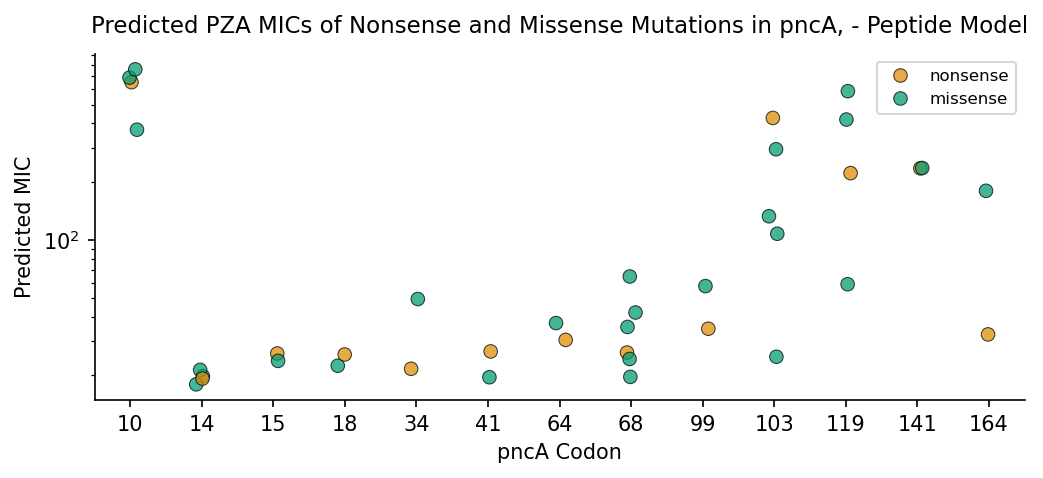

In [24]:
PZA_compare_codon_predictions = PZA_insilico_annotated.query("codon_num in @PZA_codon_summary.index.values").sort_values("codon_num")
PZA_compare_codon_predictions["mutation_type"] = ["nonsense" if "+" in val else "missense" for val in PZA_compare_codon_predictions.mutation.values]

fig, ax = plt.subplots(figsize=(8, 3))

sns.stripplot(data=PZA_compare_codon_predictions,
                x='codon_num',
                y='MIC',
                hue='mutation_type',
               dodge=False,
               jitter=True,
               s=6.5,
              linewidth=0.5,
              edgecolor='black',
              log_scale=10,
              palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green 
              alpha=0.75
              
               )

plt.legend(ncol=2)
plt.title("Predicted PZA MICs of Nonsense and Missense Mutations in pncA, - Peptide Model", fontsize=11)
plt.xlabel("pncA Codon")
plt.ylabel("Predicted MIC")
plt.legend(fontsize=8)
sns.despine()
plt.savefig("PZA/insilico_mutagenesis/nonsense_missense_comparison.png", bbox_inches="tight")

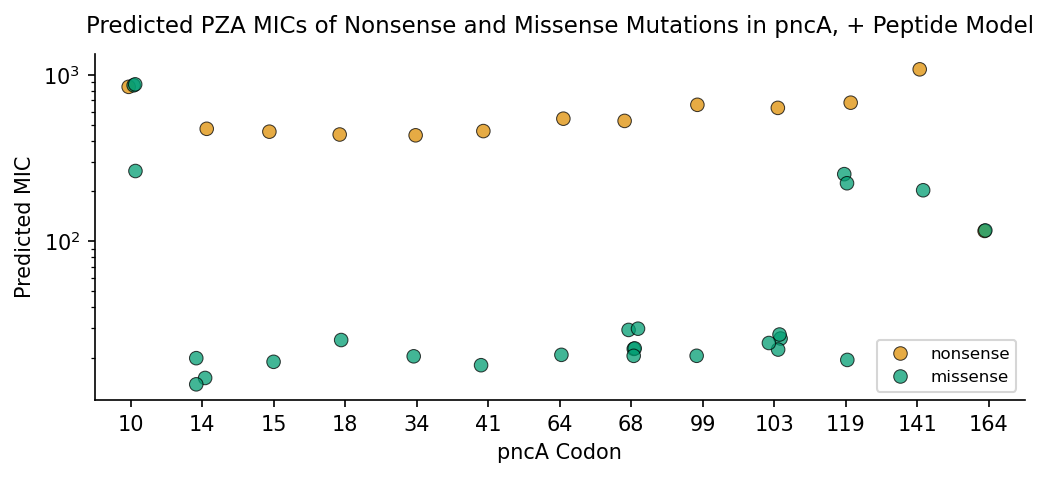

In [25]:
PZA_compare_codon_predictions_peptide = PZA_insilico_annotated_peptide.query("codon_num in @PZA_codon_summary_peptide.index.values").sort_values("codon_num")
PZA_compare_codon_predictions_peptide["mutation_type"] = ["nonsense" if "+" in val else "missense" for val in PZA_compare_codon_predictions_peptide.mutation.values]

fig, ax = plt.subplots(figsize=(8, 3))

sns.stripplot(data=PZA_compare_codon_predictions_peptide,
                x='codon_num',
                y='MIC',
                hue='mutation_type',
               dodge=False,
               jitter=True,
               s=6.5,
              linewidth=0.5,
              edgecolor='black',
              log_scale=10,
              palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
              alpha=0.75
              
               )

plt.legend(ncol=2)
plt.title("Predicted PZA MICs of Nonsense and Missense Mutations in pncA, + Peptide Model", fontsize=11)
plt.xlabel("pncA Codon")
plt.ylabel("Predicted MIC")
plt.legend(fontsize=8)
sns.despine()
plt.savefig("PZA/insilico_mutagenesis/nonsense_missense_comparison_peptide.png", bbox_inches="tight")

In [ ]:
# def plot_codon_summary_info(codon_summary_df, gene, log_base=2):

#     fig, ax = plt.subplots(figsize=(5, 4))
    
#     print(st.spearmanr(codon_summary_df['count'],
#                  codon_summary_df['MIC_range']
#                 ))
    
#     sns.stripplot(data=codon_summary_df,
#                   x='count',
#                   y='MIC_range',
#                   ax=ax,
#                   palette='colorblind',
#                   zorder=2,
#                   log_scale=log_base,
#                   linewidth=0.5,
#                   edgecolor='gray'
#                 )
    
#     sns.boxplot(data=codon_summary_df,
#                 x='count',
#                 y='MIC_range',
#                 log_scale=log_base,
#                 ax=ax,
#                 palette='colorblind',
#                 fliersize=0,
#                 zorder=1,
#                 linewidth=1,
#                 fill=False
#                 )
    
#     ax.set_title(f"Range of predicted MICs for Codons in {gene}")
#     ax.set_xlabel("Number of mutations")
#     ax.set_ylabel("Predicted MIC Range")
    
#     sns.despine()
#     plt.show()

In [ ]:
# plot_codon_summary_info(PZA_codon_summary, "pncA", log_base=10)

In [54]:
def plot_insilico_lineage_pred(drug, drug_full, mic_col="CNN_log_MIC", log_base=2, save=False):

    save_fName = f"{drug}/insilico_mutagenesis/lineage_predictions.png"

    df = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions.csv")
    df["Peptide"] = 0
    
    df_peptide = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions_peptide.csv")
    df_peptide["Peptide"] = 1

    if mic_col not in df.columns or mic_col not in df_peptide.columns:
        raise ValueError(f"{mic_col} is not a valid column name!")

    plot_col = "CNN_MIC"
    df[plot_col] = np.exp2(df[mic_col])
    df_peptide[plot_col] = np.exp2(df_peptide[mic_col])
        
    ref_lineage_mic = df.query("Lineage=='MT_H37Rv'")[plot_col].values[0]
    ref_lineage_mic_peptide = df_peptide.query("Lineage=='MT_H37Rv'")[plot_col].values[0]

    if df[plot_col].max() > 1:
        max_val = np.rint(df[plot_col].max())
        min_val = np.rint(df[plot_col].min())
        mean_val = np.rint(df[plot_col].mean())
        ref_lineage_mic = np.rint(ref_lineage_mic)

        max_val_peptide = np.rint(df_peptide[plot_col].max())
        min_val_peptide = np.rint(df_peptide[plot_col].min())
        mean_val_peptide = np.rint(df_peptide[plot_col].mean())
        ref_lineage_mic_peptide = np.rint(ref_lineage_mic_peptide)
        
    else:
        max_val = np.round(df[plot_col].max(), 2)
        min_val = np.round(df[plot_col].min(), 2)
        mean_val = np.round(df[plot_col].mean(), 2)
        ref_lineage_mic = np.round(ref_lineage_mic, 2)

        max_val_peptide = np.round(df_peptide[plot_col].max(), 2)
        min_val_peptide = np.round(df_peptide[plot_col].min(), 2)
        mean_val_peptide = np.round(df_peptide[plot_col].mean(), 2)
        ref_lineage_mic_peptide = np.round(ref_lineage_mic_peptide, 2)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
    sns.histplot(data=df, x=plot_col, stat="count", log_scale=log_base, ax=ax[0])
    sns.histplot(data=df_peptide, x=plot_col, stat="count", log_scale=log_base, ax=ax[1])
    
    ax[0].axvline(x=ref_lineage_mic, color="tomato", label=f"No SNP = {ref_lineage_mic}", linestyle="--", linewidth=1)
    ax[1].axvline(x=ref_lineage_mic_peptide, color="tomato", label=f"No SNP = {ref_lineage_mic_peptide}", linestyle="--", linewidth=1)
    
    # Force integer tick labels
    ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[1].yaxis.set_major_locator(MaxNLocator(integer=True))

    ax[0].set_title(f"NO Peptide Lengths:\nMin = {min_val}, Mean = {mean_val}, Max = {max_val}")
    ax[1].set_title(f"+ Peptide Lengths:\nMin = {min_val_peptide}, Mean = {mean_val_peptide}, Max = {max_val_peptide}")

    ax[0].set_xlabel(f"{drug_full} MIC (µg/mL)")
    ax[1].set_xlabel(f"{drug_full} MIC (µg/mL)")
    # fig.supxlabel()  # doesn't look as good
    
    ax[0].legend()
    ax[1].legend()
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(save_fName, bbox_inches="tight", dpi=300)
    else:
        plt.show()

    return pd.concat([df, df_peptide], axis=0)

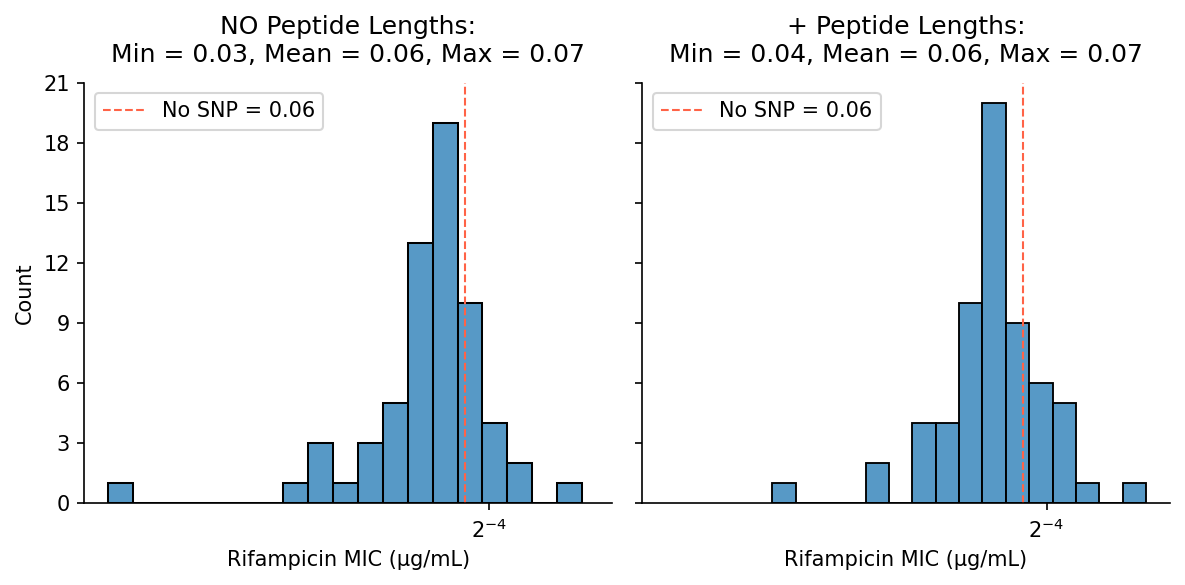

In [55]:
RIF_lineage_pred = plot_insilico_lineage_pred("RIF", "Rifampicin", "CNN_log_MIC", save=True)

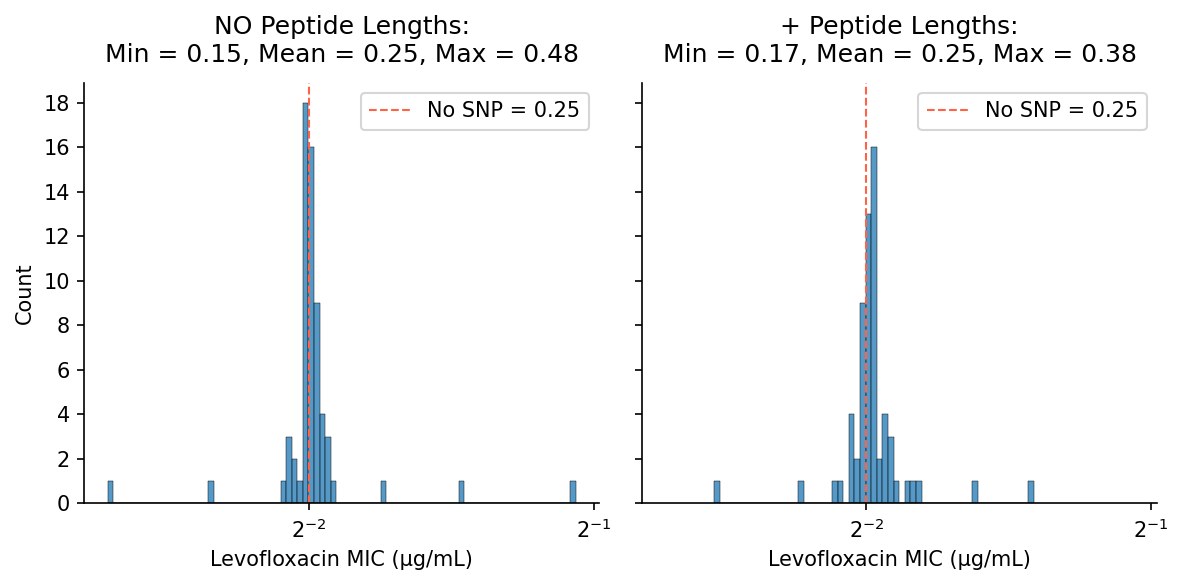

In [56]:
LEV_lineage_pred = plot_insilico_lineage_pred("LEV", "Levofloxacin", "CNN_log_MIC", save=True)

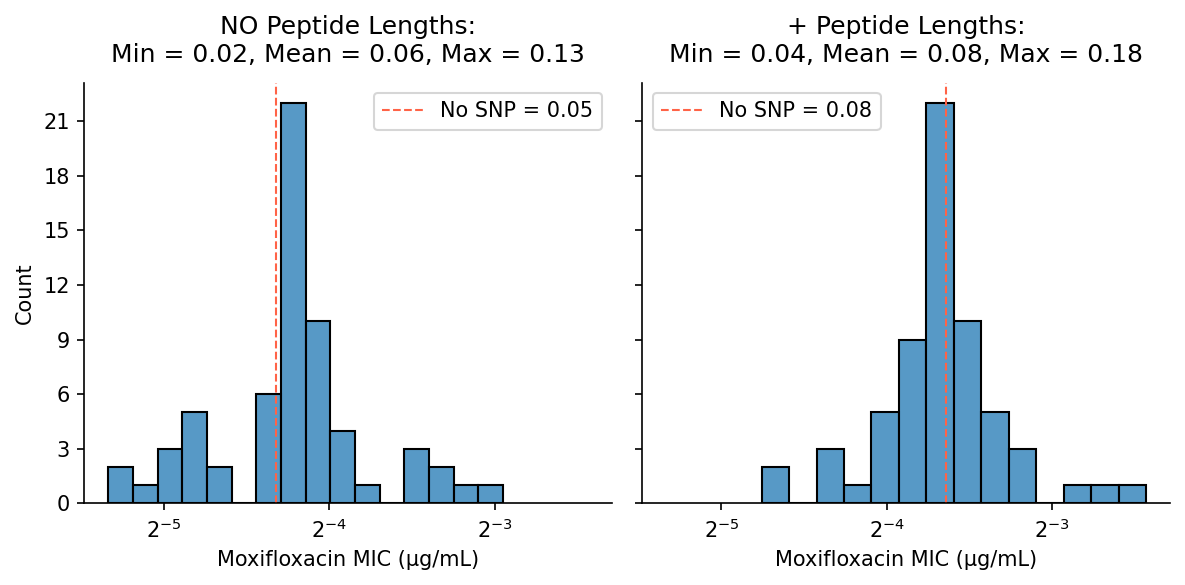

In [57]:
MXF_lineage_pred = plot_insilico_lineage_pred("MXF", "Moxifloxacin", "CNN_log_MIC", save=True)

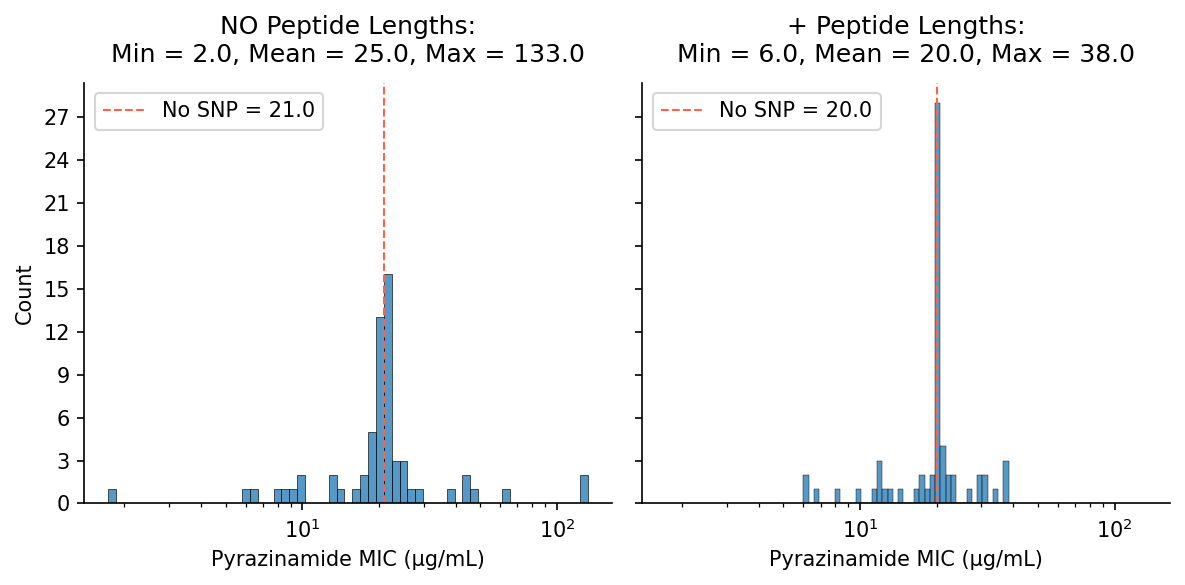

In [58]:
PZA_lineage_pred = plot_insilico_lineage_pred("PZA", "Pyrazinamide", "CNN_log_MIC", log_base=10, save=True)

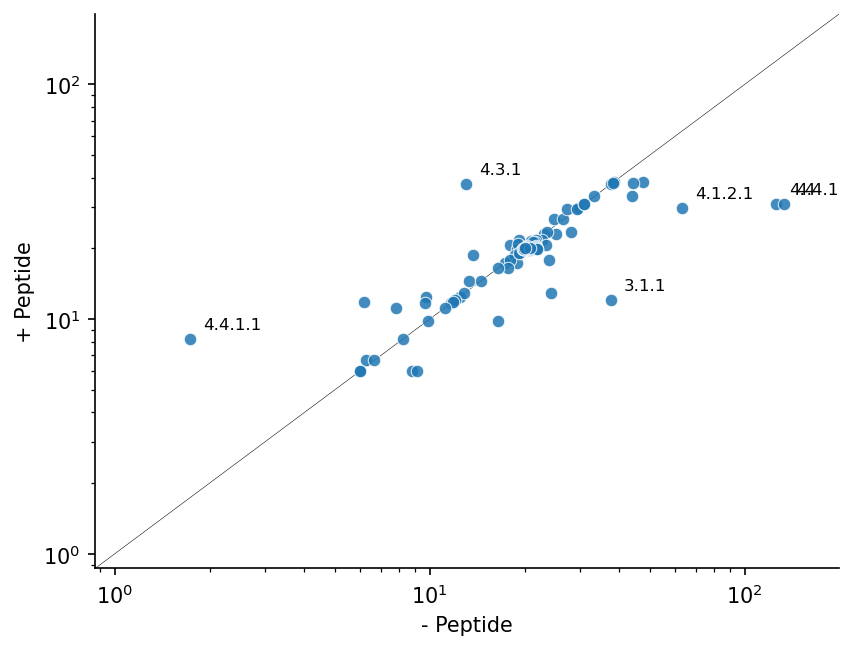

In [43]:
plot_df = PZA_lineage_pred[['Lineage', 'CNN_MIC']].rename(columns={'CNN_MIC': '- Peptide'}).merge(PZA_lineage_pred_peptide[['Lineage', 'MIC']].rename(columns={'MIC': "+ Peptide"}), on='Lineage')

fig, ax = plt.subplots()

sns.scatterplot(data=plot_df,
                x='- Peptide',
                y='+ Peptide',
                alpha=0.85,
                ax=ax
               )

plt.xscale('log', base=10)
plt.yscale('log', base=10)

min_val = plot_df[['- Peptide', '+ Peptide']].values.min() * 0.5
max_val = plot_df[['- Peptide', '+ Peptide']].values.max() * 1.5
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=0.25, zorder=0, color='black')

for i, row in plot_df.iterrows():

    diff = np.max([row['- Peptide'] / row['+ Peptide'], row['+ Peptide'] / row['- Peptide']])

    if diff >= 2:
        ax.text(row['- Peptide'] * 1.1, row['+ Peptide'] * 1.1, row['Lineage'], fontsize=8)

sns.despine()
plt.show()

# rpoB Mutations Outside the RRDR

In [71]:
RIF_insilico_annotated.query("gene == 'rpoB' & ~(codon_num >= 426 & codon_num <= 452) & MIC > 0.5")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
10,1.504441,2.837147,rpoB_p_Ile491Phe,rpoB,491,1) Assoc w R
11,8.403121,338.525570,rpoB_p_Val170Phe,rpoB,170,1) Assoc w R
593,-0.855311,0.552746,rpoB_p_Gln172Arg,rpoB,172,3) Uncertain significance


In [72]:
who_variants_V2.query("mutation=='rpoB_p.Gln172Arg'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
40973,Rifampicin,rpoB,p.Gln172Arg,rpoB_p.Gln172Arg,1,missense_variant,0.0,0.0,0.0,0.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,760321


# Putative Compensatory Mutations in rpoC

## All rpoC mutations predicted not to increase MIC much

In [128]:
# plt.figure(figsize=(6, 4))
# sns.histplot(data=RIF_insilico_annotated.query("gene=='rpoC'").MIC, log_scale=2)
# plt.axvline(x=RIF_insilico_annotated.query("mutation=='MT_H37Rv'")["MIC"].values[0], color="tomato", linestyle="--", linewidth=0.5, label="H37Rv")

# max_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.max(), 2)
# min_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.min(), 2)
# mean_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.mean(), 2)

# plt.xlabel("MIC (µg/mL)")
# plt.xticks(fontsize="9")
# plt.title(f"Predicted MICs for rpoC Mutations from the 2021 Catalog\nMin = {min_val}, Mean {mean_val}, Max = {max_val}")
# plt.legend()
# sns.despine()

# plt.savefig("Rifampicin/insilico_mutagenesis/rpoC_pred_hist.png", dpi=300)
# # plt.show()

In [40]:
# don't think this is significant, the difference is so small relative to the relevant RIF concentrations
RIF_insilico_annotated.query("gene=='rpoC'").groupby("confidence").MIC.mean()

confidence
3) Uncertain significance     0.056735
4) Not assoc w R - Interim    0.056886
5) Not assoc w R              0.055205
Name: MIC, dtype: float64

In [96]:
who_variants_V2.query("mutation=='rpoB_p.Ser441Gln'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
41405,Rifampicin,rpoB,p.Ser441Gln,rpoB_p.Ser441Gln,1,missense_variant,1.0,32.0,30.0,2.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,761127


In [42]:
RIF_insilico_annotated.query("gene=='rpoC'")['MIC'].max()

0.14361214844935122

In [43]:
RIF_insilico_annotated.query("gene=='rpoC'").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
1952,-2.799750,0.143612,rpoC_c_3643C>T,rpoC,0,4) Not assoc w R - Interim
2740,-4.017850,0.061731,rpoC_p_Ser308Phe,rpoC,308,3) Uncertain significance
2113,-4.068727,0.059592,rpoC_p_Ala1044Leu,rpoC,1044,3) Uncertain significance
2267,-4.069769,0.059549,rpoC_p_Asp1093Glu,rpoC,1093,3) Uncertain significance
2208,-4.076801,0.059260,rpoC_p_Arg247Cys,rpoC,247,3) Uncertain significance
...,...,...,...,...,...,...
1785,-4.276444,0.051601,rpoC_c_2619G>A,rpoC,0,4) Not assoc w R - Interim
2411,-4.278491,0.051528,rpoC_p_Glu489del,rpoC,489,3) Uncertain significance
2540,-4.302362,0.050683,rpoC_p_Ile491Val,rpoC,491,3) Uncertain significance
2130,-4.355979,0.048834,rpoC_p_Ala1300_Ala1303del,rpoC,1303,3) Uncertain significance


In [102]:
RIF_isolate_variants = pd.read_csv(os.path.join(data_dir, "RIF", "isolate_variants_fixed_annot.csv"))
df_RIF = pd.read_csv(os.path.join(data_dir, "RIF", "data_for_model.csv"))
RIF_pred = pd.read_csv(os.path.join(results_dir, "RIF_rpoABC_peptide_lineage", "test_predictions.csv"))

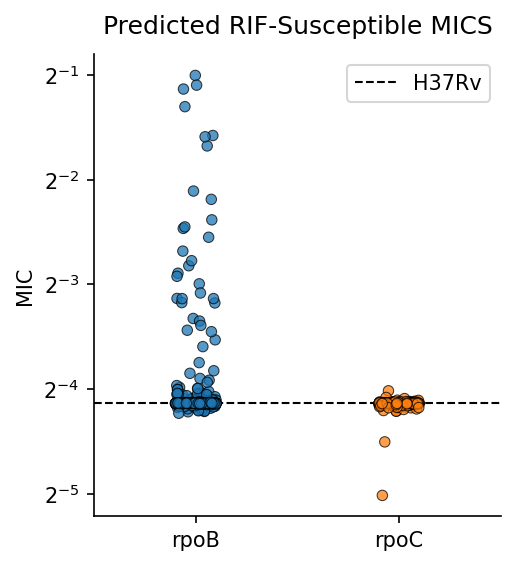

In [115]:
fig, ax = plt.subplots(figsize=(3.5, 4))

h37Rv_RIF = RIF_insilico_annotated.query("mutation=='MT_H37Rv'")['MIC'].values[0]

sns.stripplot(data=RIF_insilico_annotated.query("MIC < 0.5 & mutation != 'MT_H37Rv'"),# & (MIC > @h37Rv_RIF * 2 | MIC < @h37Rv_RIF / 2)"),
              x='gene',
              y="MIC",
              hue="gene",
              dodge=False,
              alpha=0.75,
              edgecolor="black",
              linewidth=0.5,
              log_scale=2,
              legend=False,
              ax=ax
             )

plt.axhline(y=RIF_insilico_annotated.query("mutation=='MT_H37Rv'")["MIC"].values[0], color="black", linestyle="--", linewidth=1, label='H37Rv')
plt.title("Predicted RIF-Susceptible MICS")
plt.xlabel("")
plt.legend()
sns.despine()
plt.show()
#plt.savefig("RIF/insilico_mutagenesis/susceptible_MICs.png", dpi=300, bbox_inches='tight')

In [ ]:
MXF_insilico_annotated.query("confidence not in ['1) Assoc w R', '2) Assoc w R - Interim'] & MIC > 0.5").sort_values("MIC", ascending=False)#.merge(who_variants_V2[['mutation', 'confidence']])

In [132]:
who_variants_V2[['mutation', 'confidence']]

,mutation,confidence
0,bacA_c.102G>A,4) Not assoc w R - Interim
1,bacA_c.1044G>A,5) Not assoc w R
2,bacA_c.105C>G,4) Not assoc w R - Interim
3,bacA_c.1065T>G,4) Not assoc w R - Interim
4,bacA_c.1080G>A,4) Not assoc w R - Interim
...,...,...
48016,whiB7_p.Val38Leu,3) Uncertain significance
48017,whiB7_p.Val65fs,3) Uncertain significance
48018,whiB7_p.Val65Phe,3) Uncertain significance
48019,whiB7_p.Val6Phe,3) Uncertain significance


In [133]:
RIF_insilico_annotated.query("gene=='rpoB' & MIC <= 0.5").sort_values("MIC", ascending=False).head(10)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
65,-1.004055,0.498597,rpoB_p_Asp435Gly,rpoB,435,2) Assoc w R - Interim
115,-1.097045,0.467473,rpoB_p_Gly426_Thr427del,rpoB,427,2) Assoc w R - Interim
34,-1.134364,0.455536,rpoB_p_Arg448Gln,rpoB,448,2) Assoc w R - Interim
755,-1.302650,0.405381,rpoB_p_Lys422_Thr427del,rpoB,427,3) Uncertain significance
6,-1.578222,0.334894,rpoB_p_Ser441Gln,rpoB,441,1) Assoc w R
580,-1.590348,0.332091,rpoB_p_Ile491Tyr,rpoB,491,3) Uncertain significance
90,-1.677726,0.312575,rpoB_p_Asp435del,rpoB,435,2) Assoc w R - Interim
30,-2.109177,0.231779,rpoB_p_Leu452Gln,rpoB,452,2) Assoc w R - Interim
99,-2.188417,0.219392,rpoB_p_Ser441Val,rpoB,441,2) Assoc w R - Interim
50,-2.384139,0.191559,rpoB_p_Asn437His,rpoB,437,2) Assoc w R - Interim


In [116]:
RIF_insilico_annotated.query("confidence not in ['1) Assoc w R', '2) Assoc w R - Interim']").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
593,-0.855311,0.552746,rpoB_p_Gln172Arg,rpoB,172,3) Uncertain significance
755,-1.302650,0.405381,rpoB_p_Lys422_Thr427del,rpoB,427,3) Uncertain significance
580,-1.590348,0.332091,rpoB_p_Ile491Tyr,rpoB,491,3) Uncertain significance
588,-2.774681,0.146129,rpoB_p_Ser493Leu,rpoB,493,3) Uncertain significance
699,-3.137075,0.113670,rpoB_p_Val168Gly,rpoB,168,3) Uncertain significance
...,...,...,...,...,...,...
600,-4.215041,0.053845,rpoB_p_Ile491Thr,rpoB,491,3) Uncertain significance
543,-4.218642,0.053711,rpoB_p_Ile488Val,rpoB,488,3) Uncertain significance
988,-4.232412,0.053201,rpoB_p_Ser1124Ala,rpoB,1124,3) Uncertain significance
921,-4.506032,0.044010,rpoC_p_Leu151Phe,rpoC,151,3) Uncertain significance


In [63]:
RIF_insilico_annotated.query("gene=='rpoC'").sort_values("MIC")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
1030,-5.017628,0.030870,rpoC_p_Glu1092Asp,rpoC,1092,5) Not assoc w R
921,-4.506032,0.044010,rpoC_p_Leu151Phe,rpoC,151,3) Uncertain significance
380,-4.212436,0.053942,rpoC_p_Thr909Lys,rpoC,909,3) Uncertain significance
391,-4.212365,0.053945,rpoC_p_Ile348Leu,rpoC,348,3) Uncertain significance
497,-4.206451,0.054167,rpoC_p_Glu1096Asp,rpoC,1096,3) Uncertain significance
...,...,...,...,...,...,...
847,-4.109407,0.057936,rpoC_p_Ala1299Val,rpoC,1299,3) Uncertain significance
345,-4.107497,0.058012,rpoC_p_Val626Ile,rpoC,626,3) Uncertain significance
867,-4.092235,0.058629,rpoC_p_Arg247Cys,rpoC,247,3) Uncertain significance
540,-4.081402,0.059071,rpoC_p_Ala1044Val,rpoC,1044,3) Uncertain significance


In [119]:
PZA_insilico_annotated.query("confidence=='4) Not assoc w R - Interim' & MIC > 100")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
341,6.73405,106.45134,pncA_p_Ala171Val,pncA,171,4) Not assoc w R - Interim


In [121]:
who_variants_V2.query("mutation=='pncA_p.Ala171Val'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35681,Pyrazinamide,pncA,p.Ala171Val,pncA_p.Ala171Val,1,missense_variant,1.0,9.0,3.0,6.0,...,3) Uncertain significance,NaN,DOWN from NotAwRI to Uncertain,NaN,NaN,yes,NaN,NaN,2,2288730


In [120]:
PZA_insilico_annotated.query("codon_num==170")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence


In [123]:
RIF_insilico_annotated.query("mutation=='rpoB_p_Leu430Pro'")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
20,2.252135,4.763872,rpoB_p_Leu430Pro,rpoB,430,1) Assoc w R


In [67]:
# H37Rv value
RIF_insilico_annotated.query("MIC < 0.056837").sort_values("MIC", ascending=True)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
1030,-5.017628,0.030870,rpoC_p_Glu1092Asp,rpoC,1092,5) Not assoc w R
921,-4.506032,0.044010,rpoC_p_Leu151Phe,rpoC,151,3) Uncertain significance
988,-4.232412,0.053201,rpoB_p_Ser1124Ala,rpoB,1124,3) Uncertain significance
543,-4.218642,0.053711,rpoB_p_Ile488Val,rpoB,488,3) Uncertain significance
600,-4.215041,0.053845,rpoB_p_Ile491Thr,rpoB,491,3) Uncertain significance
...,...,...,...,...,...,...
387,-4.137030,0.056837,rpoC_p_Val139Gly,rpoC,139,3) Uncertain significance
887,-4.137030,0.056837,rpoB_p_Asp3Gly,rpoB,3,3) Uncertain significance
310,-4.137029,0.056837,rpoC_p_Arg282Gln,rpoC,282,3) Uncertain significance
603,-4.137028,0.056837,rpoB_c_-83A>G,rpoB,0,3) Uncertain significance


In [68]:
who_variants_V2.query("mutation in ['rpoC_p.Glu1092Asp', 'rpoC_p.Leu151Phe']")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
42480,Rifampicin,rpoC,p.Glu1092Asp,rpoC_p.Glu1092Asp,2,missense_variant,NaN,0.0,0.0,0.0,...,5) Not assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,766645
42686,Rifampicin,rpoC,p.Leu151Phe,rpoC_p.Leu151Phe,2,missense_variant,1.0,4.0,0.0,4.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,763820


In [ ]:
rpoC_c.3643C>T associated with resistant. Must be a lineage marker

In [323]:
RIF_isolate_variants = pd.read_csv(os.path.join(data_dir, "RIF", "isolate_variants.csv.gz"), compression="gzip", usecols=['FILTER', 'AF', 'GENE', 'NUC', 'PROT', 'Isolate'])

In [329]:
PZA_isolate_variants.query("GENE=='pncA' & NUC=='c.3G>A'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,REF_len,ALT_len
1291504,2289239,C,T,PASS,0.97,pncA,initiator_codon_variant,c.3G>A,p.Met1?,Peru4940,1,1


In [331]:
df_PZA.query("ROLLINGDB_ID=='Peru4940'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
813,Peru4940,SAMN05916261,Peru4940,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,1,2,original_train_set


In [340]:
PZA_isolate_variants.query("Isolate=='Peru4940' & ((POS >= 2286527 & POS <= 2291268) | (POS >= 4042941 & POS <= 4046302) | (POS >= 4038051 & POS <= 4040980) | (POS >= 1833380 & POS <= 1836386)) & EFFECT not in ['synonymous_variant']")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,REF_len,ALT_len
1291275,1836286,G,C,PASS,1.0,coaE-Rv1632c,intergenic_region,n.1836286G>C,.,Peru4940,1,1
1291504,2289239,C,T,PASS,0.97,pncA,initiator_codon_variant,c.3G>A,p.Met1?,Peru4940,1,1


In [336]:
who_variants.query("mutation=='pncA_c.3G>A'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35634,Pyrazinamide,pncA,c.3G>A,pncA_c.3G>A,1,initiator_codon_variant,1.0,NaN,NaN,NaN,...,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0,2289239


In [326]:
RIF_isolate_variants.query("GENE=='rpoC' & NUC=='c.3643C>T'")

,FILTER,AF,GENE,NUC,PROT,Isolate
6015305,PASS,1.0,rpoC,c.3643C>T,p.Leu1215Leu,ERR4810712
6019699,PASS,1.0,rpoC,c.3643C>T,p.Leu1215Leu,ERR4810714
16570623,PASS,1.0,rpoC,c.3643C>T,p.Leu1215Leu,ERR4810711


In [350]:
RIF_isolate_variants.query("GENE=='rpoB' & NUC.str.contains('c.1332C')")

,FILTER,AF,GENE,NUC,PROT,Isolate
12896401,PASS,1.0,rpoB,c.1332C>G,p.Thr444Thr,ERR4830898
13137829,Del;LowCov,1.0,rpoB,c.1332C>G,p.Thr444Thr,ERR4831025
14102137,PASS,0.96,rpoB,c.1332C>G,p.Thr444Thr,ERR4831944
16583197,PASS,1.0,rpoB,c.1332C>G,p.Thr444Thr,1727


In [352]:
df_RIF.query("ROLLINGDB_ID in ['ERR4830898', 'ERR4831944', '1727']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
6057,ERR4831944,ERS5320891,site.08.subj.02TB1380.lab.21047.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>8.0,8.0,8.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,1,2,original_train_set
7709,1727,ERS2401239,1727,Netherlands,farhat_internal,NaN,NaN,RIVM,m7h10,1-2,1.0,1.5,2.0,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4,1,4,original_train_set


In [330]:
df_RIF = pd.read_csv(os.path.join(data_dir, "RIF", "data_for_model.csv"))
df_PZA = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [328]:
df_RIF.query("ROLLINGDB_ID in ['ERR4810712', 'ERR4810714', 'ERR4810711']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
495,ERR4810712,ERS5298739,site.02.subj.0675.lab.2014241163.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
521,ERR4810714,ERS5298741,site.02.subj.0714.lab.2014241166.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.090,0.12,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
523,ERR4810711,ERS5298738,site.02.subj.0717.lab.2014241162.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set


In [353]:
RIF_isolate_variants.query("PROT=='p.Val170Phe' & GENE=='rpoB'")

,FILTER,AF,GENE,NUC,PROT,Isolate
84115,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,1854
199775,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR2184309
1245051,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR2510621
1290834,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR2510647
1724762,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR3287600
1815713,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR3287675
3450618,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR4797028
3919331,PASS,0.99,rpoB,c.508G>T,p.Val170Phe,ERR4797289
4267890,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR4797481
7230068,PASS,1.0,rpoB,c.508G>T,p.Val170Phe,ERR4811605


In [345]:
PZA_insilico_annotated_peptide.query("mutation=='pncA_c_3G>A'")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
35,7.893691,237.814126,pncA_c_3G>A,pncA,0,4) Not assoc w R - Interim


In [211]:
# def create_ECDF_by_mutation_type(annotated_df, log_base=2, save_fName=None):

#     # remove MT_H37Rv because there is no REF and ALT
#     h37Rv_data = annotated_df.query("mutation == 'MT_H37Rv'")
#     annotated_df = annotated_df.query("mutation != 'MT_H37Rv'").reset_index(drop=True)
#     annotated_df['REF_len'] = [len(val) for val in annotated_df['REF'].values]
#     annotated_df['ALT_len'] = [len(val) for val in annotated_df['ALT'].values]
    
#     for i, row in annotated_df.iterrows():

#         if "c." in row["mutation"]:
#             annotated_df.loc[i, "predicted_effect"] = "upstream noncoding"
#         elif "p." in row["mutation"]:

#             # missense variant
#             if row["REF_len"] == row["ALT_len"]:
#                 if row["mutation"].endswith('*'):
#                     annotated_df.loc[i, "predicted_effect"] = "nonsense"
#                 else:
#                     annotated_df.loc[i, "predicted_effect"] = "missense"
#             else:
#                 # insertions
#                 if row["ALT_len"] > row["REF_len"]:
#                     # inframe: take length difference and if mod 3 = 0
#                     if (row["ALT_len"] - row["REF_len"] ) % 3 == 0:
#                         annotated_df.loc[i, "predicted_effect"] = "inframe insertion"
#                     else:
#                         annotated_df.loc[i, "predicted_effect"] = "frameshift"
#                 else:
#                     # inframe: take length difference and if mod 3 = 0
#                     if (row["REF_len"] - row["ALT_len"]) % 3 == 0:
#                         annotated_df.loc[i, "predicted_effect"] = "inframe deletion"
#                     else:
#                         annotated_df.loc[i, "predicted_effect"] = "frameshift"

#     assert len(annotated_df.loc[pd.isnull(annotated_df["predicted_effect"])]) == 0
    
#     df_plot = annotated_df.drop_duplicates("mutation", keep="first")


#     fig, ax = plt.subplots(figsize=(5, 4))
#     sns.ecdfplot(data=df_plot, 
#                  x="MIC", 
#                  hue="predicted_effect", 
#                  hue_order=df_plot.groupby("predicted_effect")["MIC"].mean().sort_values(ascending=False).index.values,
#                  palette="colorblind",
#                  log_scale=log_base,
#                  ax=ax
#                 )

#     plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
#     plt.ylabel("Proportion",  fontsize=8)
#     plt.title(f"Predicted MICs of {len(df_plot)} WHO Catalog Mutations\n", fontsize=10)

#     # plt.xlim(df_plot["log_MIC"].min()*1.1, df_plot["log_MIC"].max())

#     # fig.legend(labels=df["confidence"].unique())
#     sns.move_legend(ax, fontsize=8, title='', loc='lower right')
#     # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
#     plt.xticks(fontsize=8)
#     plt.yticks(fontsize=8)
#     sns.despine()
    
#     if save_fName is None:
#         plt.show()
#     else:
#         plt.savefig(save_fName, dpi=300)

#     return pd.concat([annotated_df, h37Rv_data], axis=0)

# Plot Distribution of Predicted MICs

In [80]:
def plot_ECDF(df, log_base=2, col="MIC", saveName=None):

    df = df.loc[~pd.isnull(df["confidence"])].drop_duplicates("mutation")
    print(df.groupby("confidence")[col].agg(['mean', 'median']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=df, 
                 x=col, 
                 hue="confidence", 
                 hue_order=np.sort(df["confidence"].unique()),
                 palette=dict(zip(['1) Assoc w R', '2) Assoc w R - Interim', '3) Uncertain significance', '4) Not assoc w R - Interim', '5) Not assoc w R'], sns.color_palette("colorblind").as_hex())),
                 ax=ax,
                 log_scale=log_base, # for PZA, set to 10 to spread out the graph
                 zorder=3
                )
    
    # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {len(df.mutation.unique())} WHO Catalog Mutations\n", fontsize=10)
    
    y = df[col]
    plt.xlim(y.min()*1.1, y.max()*1.1)

    sns.move_legend(ax, fontsize=8, title='', ncol=1, loc='upper right', bbox_to_anchor=(1.5, 0.6))
    # sns.move_legend(ax, fontsize=8, title='', ncol=5, loc='upper right', bbox_to_anchor=(0, -0.1))#, bbox_to_anchor=(1.5, 0.6))
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

                                mean     median
confidence                                     
1) Assoc w R               47.358035  15.219120
2) Assoc w R - Interim     11.541038   0.467473
3) Uncertain significance   0.058330   0.056831
5) Not assoc w R            0.055561   0.056778


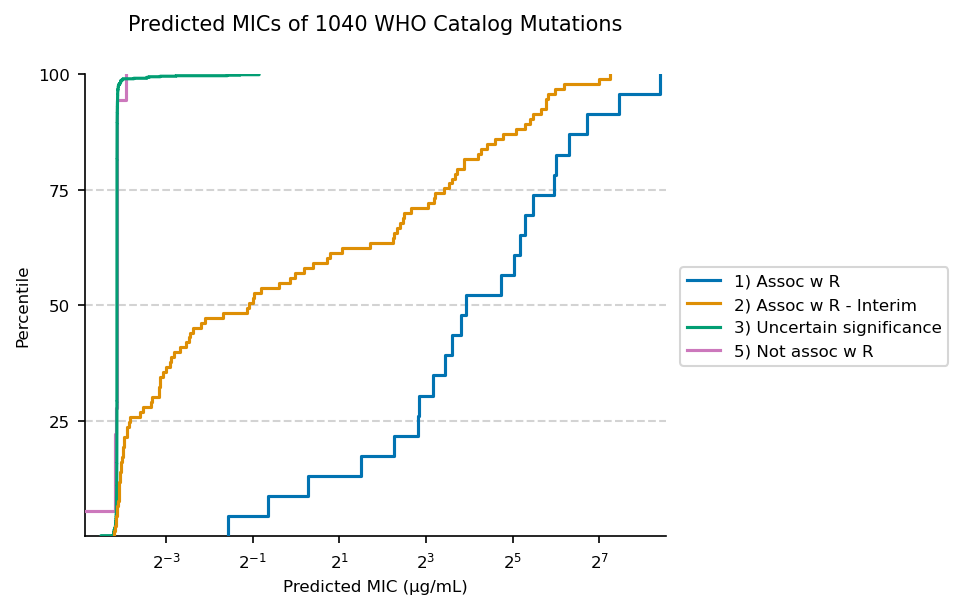

In [81]:
plot_ECDF(RIF_insilico_annotated, log_base=2, saveName="RIF/insilico_mutagenesis/WHO_rpoBC_ECDF.png")

In [78]:
RIF_insilico_annotated.query("confidence not in ['1) Assoc w R', '2) Assoc w R - Interim'] & MIC > 0.5")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
593,-0.855311,0.552746,rpoB_p_Gln172Arg,rpoB,172,3) Uncertain significance


In [84]:
who_variants_V2.query("mutation in ['rpoB_p.Gln172Arg', 'rpoB_p.Ile491Tyr']")[['Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
40973,0.0,0.0,9.0,0.0
41188,3.0,0.0,3.0,0.0


                                mean    median
confidence                                    
1) Assoc w R                0.897328  0.640345
2) Assoc w R - Interim      0.242117  0.142096
3) Uncertain significance   0.088141  0.077284
4) Not assoc w R - Interim  0.174427  0.174427
5) Not assoc w R            0.075321  0.077107


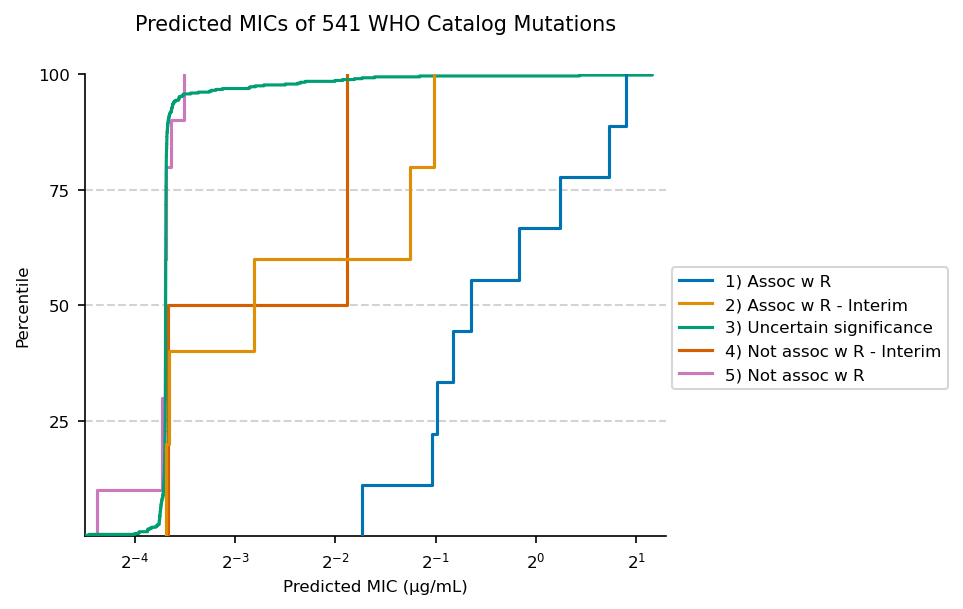

In [85]:
plot_ECDF(MXF_insilico_lineage_annotated, log_base=2, saveName="MXF/insilico_mutagenesis/WHO_gyrBA_ECDF.png")

                                   mean     median
confidence                                        
1) Assoc w R                 654.925617  49.068987
2) Assoc w R - Interim      1670.751078  56.977523
3) Uncertain significance     46.353433  25.476743
4) Not assoc w R - Interim    27.326677  24.585878


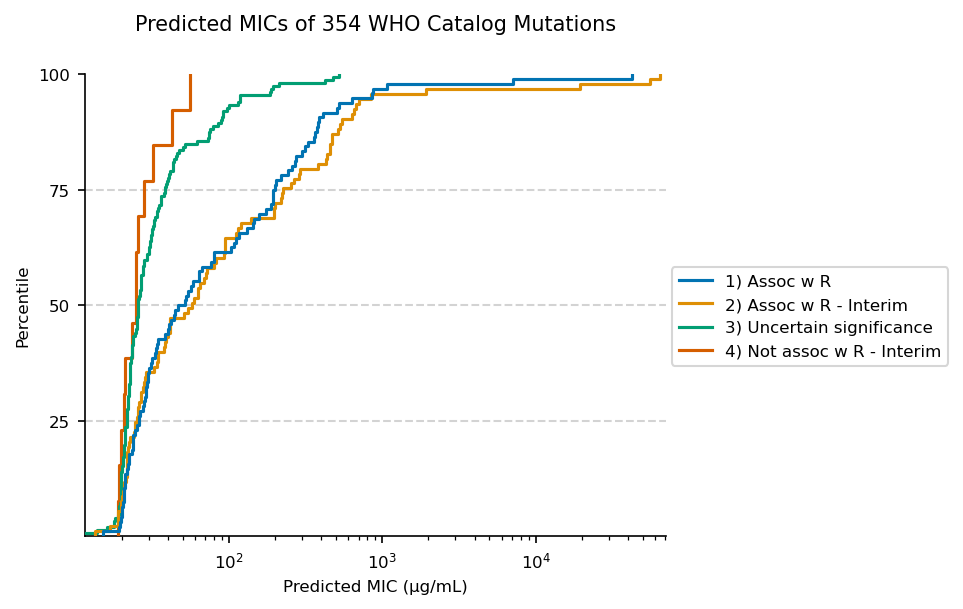

In [86]:
plot_ECDF(PZA_insilico_annotated_peptide, log_base=10, saveName="PZA/insilico_mutagenesis/WHO_pncA_ECDF_peptide.png")

In [87]:
PZA_insilico_annotated_peptide.query("confidence=='2) Assoc w R - Interim' & MIC > 500")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
96,15.775558,56093.967215,pncA_p_Asp126_Val130del,pncA,130,2) Assoc w R - Interim
99,14.244072,19404.074456,pncA_p_Gly132_Thr135del,pncA,135,2) Assoc w R - Interim
101,15.978895,64584.260703,pncA_p_Thr160_Ala171del,pncA,171,2) Assoc w R - Interim
108,9.085964,543.435122,pncA_p_Tyr64+,pncA,64,2) Assoc w R - Interim
118,9.362703,658.346367,pncA_p_Tyr99+,pncA,99,2) Assoc w R - Interim
119,8.998401,511.432843,pncA_p_Asp8Glu,pncA,8,2) Assoc w R - Interim
127,10.921404,1939.412537,pncA_p_Ala3_Ile5del,pncA,5,2) Assoc w R - Interim
128,9.304824,632.457182,pncA_p_Pro54_Asp56del,pncA,56,2) Assoc w R - Interim
136,9.405045,677.954668,pncA_p_Trp119+,pncA,119,2) Assoc w R - Interim
137,9.041697,527.014008,pncA_p_Trp68+,pncA,68,2) Assoc w R - Interim


In [90]:
PZA_insilico_annotated_peptide.sort_values("MIC", ascending=False).head(10)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
101,15.978895,64584.260703,pncA_p_Thr160_Ala171del,pncA,171,2) Assoc w R - Interim
96,15.775558,56093.967215,pncA_p_Asp126_Val130del,pncA,130,2) Assoc w R - Interim
39,15.372109,42409.768872,pncA_p_Asp129_Val131del,pncA,131,1) Assoc w R
99,14.244072,19404.074456,pncA_p_Gly132_Thr135del,pncA,135,2) Assoc w R - Interim
44,12.801373,7138.340478,pncA_p_Glu127_Asp129del,pncA,129,1) Assoc w R
127,10.921404,1939.412537,pncA_p_Ala3_Ile5del,pncA,5,2) Assoc w R - Interim
46,10.070174,1075.039534,pncA_p_Gln141+,pncA,141,1) Assoc w R
35,9.770749,873.551531,pncA_p_Gln10Arg,pncA,10,1) Assoc w R
17,9.751575,862.018188,pncA_p_Gln10Pro,pncA,10,1) Assoc w R
165,9.720975,843.927351,pncA_p_Gln10+,pncA,10,2) Assoc w R - Interim


In [96]:
PZA_insilico_annotated_peptide.query("mutation != 'MT_H37Rv'").query("~mutation.str.contains('\\+')").groupby("confidence")['MIC'].agg(['mean', 'median'])

,mean,median
confidence,,
1) Assoc w R,652.085488,44.132299
2) Assoc w R - Interim,1862.713433,40.467188
3) Uncertain significance,46.353433,25.476743
4) Not assoc w R - Interim,27.326677,24.585878


In [102]:
PZA_insilico_annotated_peptide.query("mutation != 'MT_H37Rv'").query("mutation.str.contains('del')").sort_values("MIC", ascending=False).head(20)

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
101,15.978895,64584.260703,pncA_p_Thr160_Ala171del,pncA,171,2) Assoc w R - Interim
96,15.775558,56093.967215,pncA_p_Asp126_Val130del,pncA,130,2) Assoc w R - Interim
39,15.372109,42409.768872,pncA_p_Asp129_Val131del,pncA,131,1) Assoc w R
99,14.244072,19404.074456,pncA_p_Gly132_Thr135del,pncA,135,2) Assoc w R - Interim
44,12.801373,7138.340478,pncA_p_Glu127_Asp129del,pncA,129,1) Assoc w R
127,10.921404,1939.412537,pncA_p_Ala3_Ile5del,pncA,5,2) Assoc w R - Interim
128,9.304824,632.457182,pncA_p_Pro54_Asp56del,pncA,56,2) Assoc w R - Interim
104,8.571755,380.500622,pncA_p_Gly17_Ala25del,pncA,25,2) Assoc w R - Interim
126,6.316186,79.682223,pncA_p_Gly55del,pncA,55,2) Assoc w R - Interim
110,5.372592,41.429658,pncA_p_Asp63_Ser67delinsGlu,pncA,67,2) Assoc w R - Interim


In [104]:
PZA_insilico_annotated_peptide.query("mutation != 'MT_H37Rv'").query("mutation.str.contains('del') & mutation.str.contains('_c.')")

,CNN_log_MIC,MIC,mutation,gene,codon_num,confidence
81,4.425482,21.488343,pncA_c_-5delG,pncA,0,1) Assoc w R


In [105]:
who_variants_V2.query("mutation=='pncA_p.Ala3_Ile5del'")[['mutation', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_S', 'Present_R']]

,mutation,Present_SOLO_R,Present_SOLO_S,Present_S,Present_R
35690,pncA_p.Ala3_Ile5del,1.0,0.0,0.0,1.0
